# Исследование фичей для pump.fun токенов (классификация, бинарный таргет)

## О чём этот ноутбук?

Тот же анализ что и в `feature_research.ipynb`, но **на бинарном таргете**:
- `target_3h_5x_h` = 1 если токен вырос в 5x+ за 3 часа после mig+60s, иначе 0.
- Base rate: 11.05% (357 пампов из 3231 токенов).

## Отличия от регрессионной версии

Некоторые метрики изменены под классификацию:
- **MSE reduction** → **Gini reduction** (уменьшение Gini\-impurity при binary split)
- **Pearson на log(target)** → **Pearson на бинарных значениях**
- **Decile monotonicity** — вместо медианы log(target) смотрим P(target=1) в каждой децили
- **Top vs bottom decile lift** — вместо log-лифта медиан смотрим отношение P(target=1) в крайних децилях

Остальные метрики те же:
- Spearman correlation
- Top-decile P(target=1) — практическая precision
- Биномиальный тест значимости

## 77 фичей

Включены все 75 базовых фичей B' + 2 heavy_seller (`heavy_seller_count_fw`, `heavy_seller_ratio_fw`).

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 100
plt.style.use('default')

# Загружаем данные (continuous target), потом binary-изуем
MATRIX_PATH = "/tmp/b_prime_dataset_export/b_prime_training_matrix_xcont_77.csv"
OUT_SUMMARY = "/tmp/feature_research/feature_influence_binary_summary.csv"

df = pd.read_csv(MATRIX_PATH)
TARGET_CONT = "x_excl_top1_3h_h"
df["target"] = (df[TARGET_CONT] >= 5).astype(int)
df = df.drop(columns=TARGET_CONT)

features = [c for c in df.columns if c != "target"]
y = df["target"].values
base_rate = y.mean()
print(f"Dataset: {df.shape}")
print(f"Features: {len(features)}")
print(f"Target: binary target_3h_5x_h")
print(f"Pos: {int(y.sum())}  Neg: {len(y) - int(y.sum())}")
print(f"Base rate: {base_rate:.4f}")

Dataset: (3231, 78)
Features: 77
Target: binary target_3h_5x_h
Pos: 357  Neg: 2874
Base rate: 0.1105


## 1. Метрики для бинарного таргета

### Метрика 1: Spearman correlation
**ELI5**: Отсортируй по фиче. Токены с target=1 в основном сверху или снизу? Даёт число от -1 до 1. Для бинарного таргета это немного странно, но работает — показывает направление.

### Метрика 2: Pearson на бинарном таргете
**ELI5**: Линейная корреляция между фичей и 0/1. Похожа на Spearman.

### Метрика 3: Decile monotonicity R²
**ELI5**: Разбиваем на 10 групп по значению фичи. В каждой группе считаем долю target=1. Если с ростом децили доля монотонно растёт — R² ~ 1. Если прыгает — R² низкий.

### Метрика 4: Gini reduction (вместо MSE для регрессии)
**ELI5**: Аналог MSE reduction, но для классификации. Ищем лучший single split на фиче, который максимально уменьшает Gini impurity = 2p(1-p). Чем больше gini_reduction, тем лучше фича делит positives от negatives.

### Метрика 5: Top vs bottom decile P(target=1) ratio
**ELI5**: Отношение P(target=1) в верхних 10% к нижним 10% по фиче. Если фича действительно различает — ratio >> 1.

### Метрика 6: Top-decile P(target=1) — practical precision
**ELI5**: Если мы будем флагать только топ-10% токенов по этой фиче, какую precision получим? Сравниваем с base rate = 11%.

## 2. Вычисляем

In [2]:
def gini_reduction(x, y_arr, min_side=30):
    """Уменьшение Gini при лучшем binary split."""
    order = np.argsort(x)
    x_s = x[order]; y_s = y_arr[order].astype(np.int64)
    n = len(y_s)
    if n < 2 * min_side: return 0.0
    total_pos = y_s.sum()
    p_base = total_pos / n
    g_base = 2 * p_base * (1 - p_base)
    cum_pos = np.cumsum(y_s)
    i_arr = np.arange(n - 1)
    n_l = i_arr + 1; n_r = n - n_l
    pos_l = cum_pos[:-1]; pos_r = total_pos - pos_l
    p_l = pos_l / n_l; p_r = pos_r / n_r
    g_l = 2 * p_l * (1 - p_l); g_r = 2 * p_r * (1 - p_r)
    weighted = (n_l * g_l + n_r * g_r) / n
    valid = (n_l >= min_side) & (n_r >= min_side) & (x_s[:-1] != x_s[1:])
    if not valid.any(): return 0.0
    weighted[~valid] = np.inf
    return float(g_base - weighted.min())


def decile_monotonicity_r2(x, y_arr):
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    if len(q_edges) < 3: return 0.0
    bins = np.digitize(x, q_edges[1:-1])
    pct = np.array([y_arr[bins == i].mean()
                    for i in range(len(q_edges)-1) if (bins==i).sum() > 0])
    if len(pct) < 3: return 0.0
    ranks = np.arange(len(pct))
    slope, intercept, r, p, se = stats.linregress(ranks, pct)
    return r ** 2


def top_bot_decile_ratio(x, y_arr):
    q10, q90 = np.quantile(x, [0.1, 0.9])
    top_p = y_arr[x >= q90].mean() if (x >= q90).any() else 0
    bot_p = y_arr[x <= q10].mean() if (x <= q10).any() else 0
    return top_p, bot_p, (top_p / bot_p if bot_p > 0 else float('inf'))


print(f'Считаю метрики для {len(features)} фичей...')
rows = []
for f in features:
    x = df[f].values.astype(float)
    if np.all(x == x[0]): continue
    sp, _ = stats.spearmanr(x, y)
    pe, _ = stats.pearsonr(x, y)
    monot = decile_monotonicity_r2(x, y)
    gr = gini_reduction(x, y)
    top_p, bot_p, ratio = top_bot_decile_ratio(x, y)
    rows.append({
        'feature': f,
        'spearman': sp,
        'pearson': pe,
        'decile_monot_r2_signed': monot * np.sign(sp),
        'gini_reduction': gr,
        'top_decile_prec': top_p,
        'bottom_decile_prec': bot_p,
        'top_over_bottom_ratio': ratio,
    })

summary = pd.DataFrame(rows)
summary.to_csv(OUT_SUMMARY, index=False)
print(f'Сохранил: {OUT_SUMMARY}')
print(f'\nBase rate: {base_rate:.4f}')
print(f'Всего в summary: {len(summary)}')

Считаю метрики для 77 фичей...
Сохранил: /tmp/feature_research/feature_influence_binary_summary.csv

Base rate: 0.1105
Всего в summary: 77


## 3. Топ-20 по каждой метрике

In [3]:
print('ТОП-20 по |Spearman|:')
print((summary.reindex(summary['spearman'].abs().sort_values(ascending=False).index)
       [['feature', 'spearman', 'pearson', 'decile_monot_r2_signed',
         'gini_reduction', 'top_decile_prec', 'top_over_bottom_ratio']]
       .head(20).to_string(index=False, float_format=lambda x: f'{x:.4f}')))

ТОП-20 по |Spearman|:
              feature  spearman  pearson  decile_monot_r2_signed  gini_reduction  top_decile_prec  top_over_bottom_ratio
       unique_sellers   -0.1494  -0.1158                 -0.7689          0.0046           0.0613                 0.2740
   unique_sellers_ext   -0.1494  -0.1158                 -0.7689          0.0046           0.0613                 0.2740
sell_transactions_ext   -0.1323  -0.0982                 -0.8635          0.0041           0.0523                 0.3010
           sell_count   -0.1323  -0.0982                 -0.8635          0.0041           0.0523                 0.3010
heavy_seller_count_fw   -0.1313  -0.0842                 -0.7940          0.0039           0.0449                 0.2516
top20_token_share_ext    0.1284   0.1618                  0.5953          0.0052           0.2160                 2.1875
       sell_size_gini    0.1269   0.0792                  0.9289          0.0030           0.1667                 3.1765
          

In [4]:
print('ТОП-20 по Gini reduction (лучший binary split):')
print('(чем выше, тем лучше единичный split отделяет positives)\n')
print((summary.sort_values('gini_reduction', ascending=False)
       [['feature', 'spearman', 'pearson', 'decile_monot_r2_signed',
         'gini_reduction', 'top_decile_prec', 'top_over_bottom_ratio']]
       .head(20).to_string(index=False, float_format=lambda x: f'{x:.4f}')))

ТОП-20 по Gini reduction (лучший binary split):
(чем выше, тем лучше единичный split отделяет positives)

              feature  spearman  pearson  decile_monot_r2_signed  gini_reduction  top_decile_prec  top_over_bottom_ratio
top20_token_share_ext    0.1284   0.1618                  0.5953          0.0052           0.2160                 2.1875
       unique_sellers   -0.1494  -0.1158                 -0.7689          0.0046           0.0613                 0.2740
   unique_sellers_ext   -0.1494  -0.1158                 -0.7689          0.0046           0.0613                 0.2740
sell_transactions_ext   -0.1323  -0.0982                 -0.8635          0.0041           0.0523                 0.3010
           sell_count   -0.1323  -0.0982                 -0.8635          0.0041           0.0523                 0.3010
heavy_seller_count_fw   -0.1313  -0.0842                 -0.7940          0.0039           0.0449                 0.2516
     pa_buy_vol_share    0.0902   0.0918       

In [5]:
print('ТОП-20 по |decile monotonicity R²|:')
print('(насколько ровно доля positives растёт с децилями фичи)\n')
print((summary.reindex(summary['decile_monot_r2_signed'].abs().sort_values(ascending=False).index)
       [['feature', 'spearman', 'decile_monot_r2_signed',
         'gini_reduction', 'top_decile_prec', 'top_over_bottom_ratio']]
       .head(20).to_string(index=False, float_format=lambda x: f'{x:.4f}')))

ТОП-20 по |decile monotonicity R²|:
(насколько ровно доля positives растёт с децилями фичи)

                      feature  spearman  decile_monot_r2_signed  gini_reduction  top_decile_prec  top_over_bottom_ratio
                kolscan_count   -0.0707                 -0.9767          0.0009           0.0732                 0.5812
               sell_size_gini    0.1269                  0.9289          0.0030           0.1667                 3.1765
                buy_size_gini    0.1186                  0.8862          0.0034           0.1574                 2.8333
       amount_of_instructions   -0.0533                 -0.8805          0.0006           0.0778                 0.6383
                  deals_count   -0.1221                 -0.8729          0.0031           0.0556                 0.3673
                 n_trades_ext   -0.1221                 -0.8729          0.0031           0.0556                 0.3673
                   sell_count   -0.1323                 -0.8635    

In [6]:
print('ТОП-20 по top-decile precision (практика):')
print('(в топ 10% токенов по фиче — какая доля достигает x>=5?)\n')
print((summary.sort_values('top_decile_prec', ascending=False)
       [['feature', 'spearman', 'top_decile_prec', 'bottom_decile_prec',
         'top_over_bottom_ratio', 'gini_reduction']]
       .head(20).to_string(index=False, float_format=lambda x: f'{x:.4f}')))

ТОП-20 по top-decile precision (практика):
(в топ 10% токенов по фиче — какая доля достигает x>=5?)

                         feature  spearman  top_decile_prec  bottom_decile_prec  top_over_bottom_ratio  gini_reduction
           top20_token_share_ext    0.1284           0.2160              0.0988                 2.1875          0.0052
                pa_max_runup_pct    0.1041           0.2068              0.0864                 2.3929          0.0024
         pa_velocity_pct_per_sec    0.0717           0.1914              0.0957                 2.0000          0.0021
             pa_price_change_pct    0.0725           0.1914              0.0988                 1.9375          0.0020
 top20_unrealized_profit_usd_ext    0.0492           0.1914              0.1358                 1.4091          0.0023
volume_weighted_price_change_ext    0.0127           0.1883              0.1944                 0.9683          0.0025
                deals_count_gini   -0.0159           0.1852       

## 4. Combined score

Тот же подход: нормируем каждую метрику в [0,1] и складываем.

In [7]:
def rescale01(s):
    s = s.abs()
    s_min = s.min(); s_max = s.max()
    if s_max == s_min: return s * 0
    return (s - s_min) / (s_max - s_min)

combo_cols = ['spearman', 'pearson', 'decile_monot_r2_signed',
              'gini_reduction', 'top_decile_prec']
combo = summary.copy()
for c in combo_cols:
    combo[f'{c}_n'] = rescale01(summary[c])
combo['combined_score'] = combo[[f'{c}_n' for c in combo_cols]].sum(axis=1)
combo_sorted = combo.sort_values('combined_score', ascending=False).reset_index(drop=True)

print('ТОП-25 по combined score:')
print(combo_sorted.head(25)[['feature', 'spearman', 'pearson', 'gini_reduction',
                              'top_decile_prec', 'combined_score']].to_string(index=False,
    float_format=lambda x: f'{x:.4f}'))

ТОП-25 по combined score:
                      feature  spearman  pearson  gini_reduction  top_decile_prec  combined_score
        top20_token_share_ext    0.1284   0.1618          0.0052           0.2160          4.4685
               sell_size_gini    0.1269   0.0792          0.0030           0.1667          3.5758
           unique_sellers_ext   -0.1494  -0.1158          0.0046           0.0613          3.4796
               unique_sellers   -0.1494  -0.1158          0.0046           0.0613          3.4796
                   sell_count   -0.1323  -0.0982          0.0041           0.0523          3.2061
        sell_transactions_ext   -0.1323  -0.0982          0.0041           0.0523          3.2061
             pa_buy_vol_share    0.0902   0.0918          0.0036           0.1790          3.1715
sn_first_30s_top1_buyer_share    0.0945   0.0898          0.0018           0.1667          3.1138
                buy_size_gini    0.1186  -0.0007          0.0034           0.1574          3

## 5. Детальный разбор топ-10 фичей

Для каждой топ-10 фичи показываем:
- **Левый график** — децили: доля target=1 по децилям фичи (синяя линия)
- **Правый график** — box plot раздельно для target=0 и target=1 (красная серая коробки)

ТОП-10 фичей:
   1. top20_token_share_ext
   2. sell_size_gini
   3. unique_sellers_ext
   4. unique_sellers
   5. sell_count
   6. sell_transactions_ext
   7. pa_buy_vol_share
   8. sn_first_30s_top1_buyer_share
   9. buy_size_gini
  10. deals_count


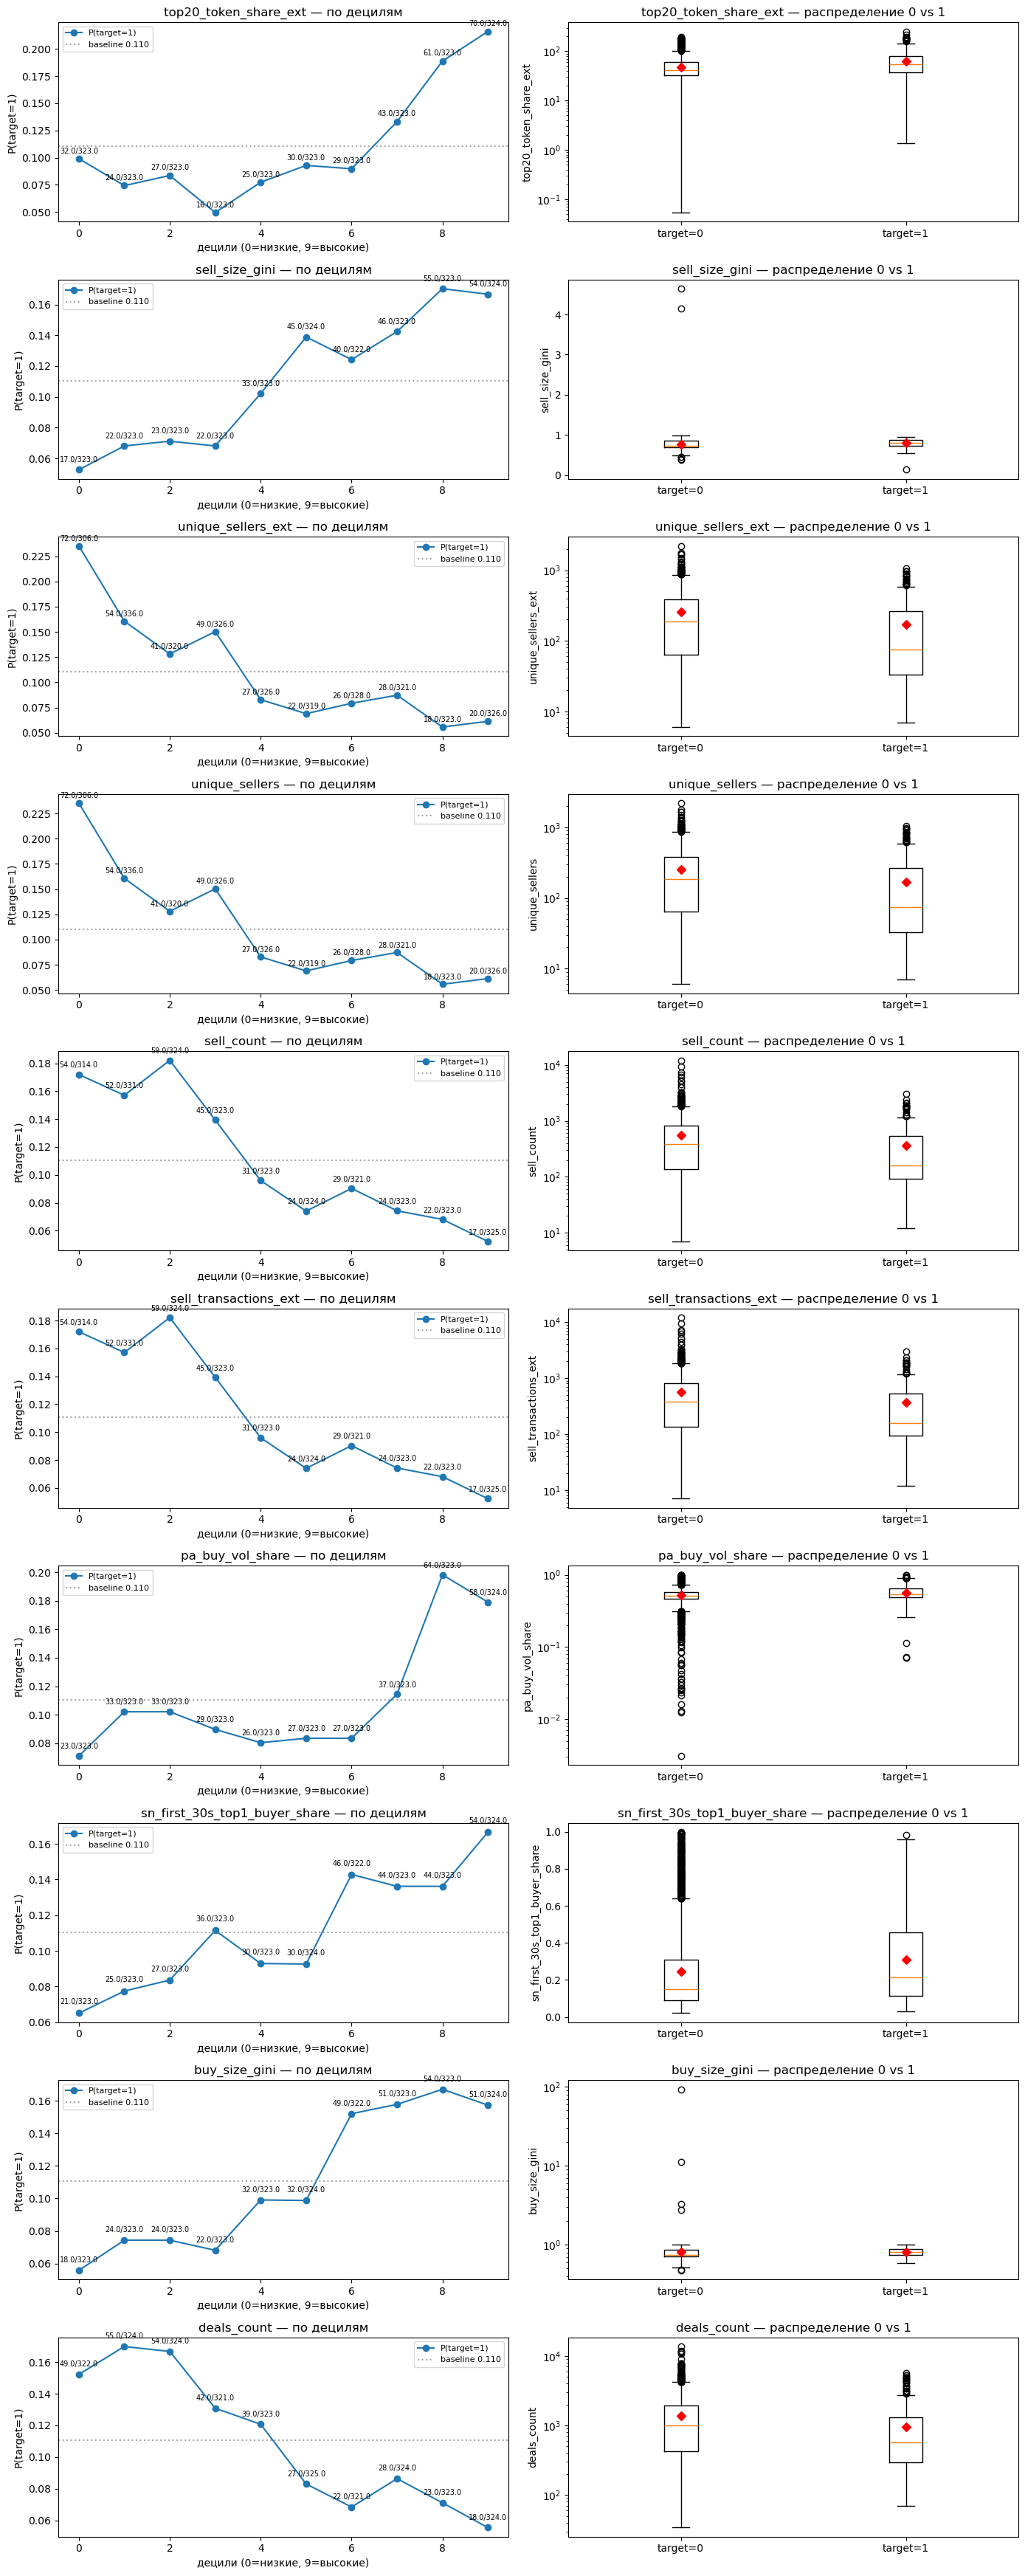

In [8]:
top10 = combo_sorted.head(10)['feature'].tolist()
print('ТОП-10 фичей:')
for i, f in enumerate(top10, 1):
    print(f'  {i:2d}. {f}')

fig, axes = plt.subplots(10, 2, figsize=(14, 3.5 * 10))
for i, feat in enumerate(top10):
    x = df[feat].values.astype(float)
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    bins = np.digitize(x, q_edges[1:-1])

    decile_stats = []
    for b in range(len(q_edges) - 1):
        m = bins == b
        if m.sum() == 0: continue
        decile_stats.append({
            'bin': b, 'n': int(m.sum()),
            'prec': float(y[m].mean()),
            'pos': int(y[m].sum()),
        })
    ds = pd.DataFrame(decile_stats)

    ax = axes[i, 0]
    ax.plot(ds['bin'], ds['prec'], 'o-', color='C0', label='P(target=1)')
    ax.axhline(base_rate, color='gray', linestyle=':', alpha=0.7, label=f'baseline {base_rate:.3f}')
    ax.set_title(f'{feat} — по децилям')
    ax.set_xlabel('децили (0=низкие, 9=высокие)')
    ax.set_ylabel('P(target=1)')
    ax.legend(fontsize=8)
    # annotate n
    for _, r in ds.iterrows():
        ax.text(r['bin'], r['prec'] + 0.005, f'{r["pos"]}/{r["n"]}', ha='center', fontsize=7)

    # Box plot
    ax = axes[i, 1]
    pos_vals = x[y == 1]; neg_vals = x[y == 0]
    ax.boxplot([neg_vals, pos_vals], labels=['target=0', 'target=1'], showmeans=True,
               meanprops={'marker':'D', 'markerfacecolor':'red', 'markeredgecolor':'red'})
    ax.set_title(f'{feat} — распределение 0 vs 1')
    ax.set_ylabel(feat)
    # log scale if appropriate
    mx = x.max(); mn = max(x.min(), 1e-10)
    if mx > 0 and mn > 0 and mx / mn > 100:
        ax.set_yscale('log')
plt.tight_layout()
plt.savefig('/tmp/feature_research/top10_features_binary.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Корреляция между топ-15

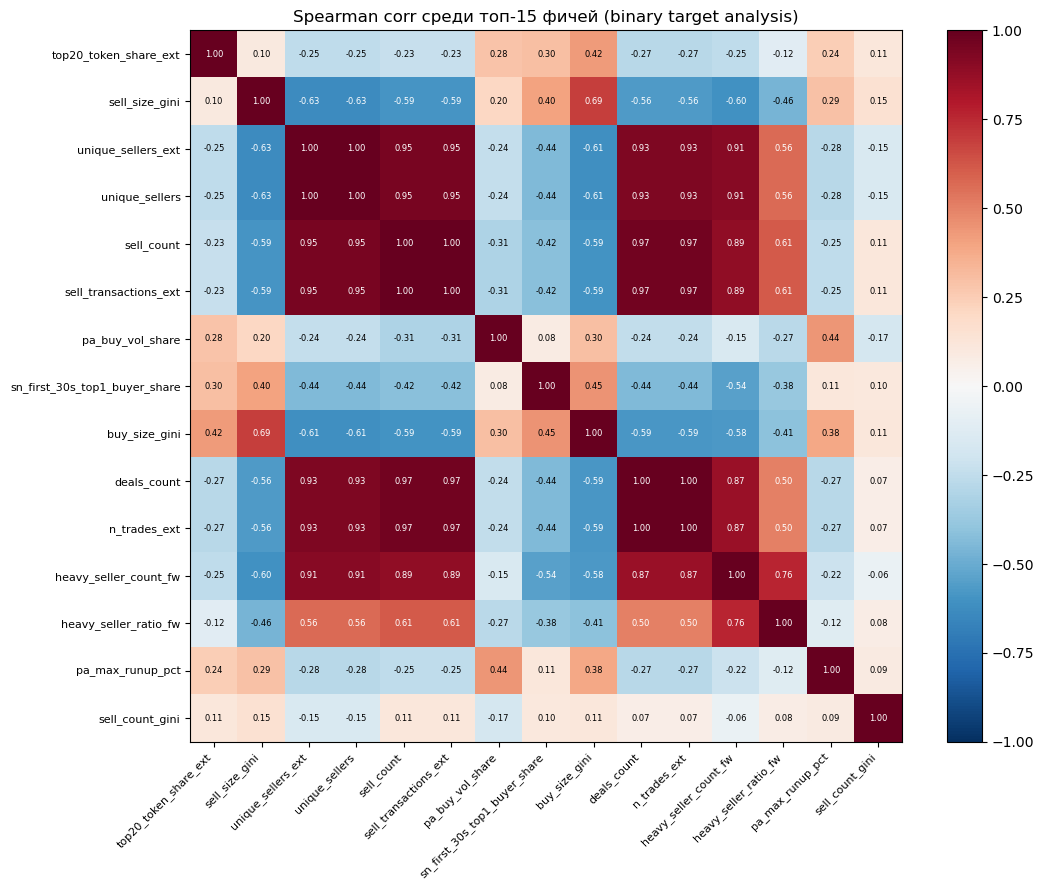

In [9]:
top15 = combo_sorted.head(15)['feature'].tolist()
corr_m = df[top15].corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_m, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(15)); ax.set_xticklabels(top15, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(15)); ax.set_yticklabels(top15, fontsize=8)
for i in range(15):
    for j in range(15):
        val = corr_m.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=6)
ax.set_title('Spearman corr среди топ-15 фичей (binary target analysis)')
plt.tight_layout()
plt.savefig('/tmp/feature_research/top15_correlation_binary.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Биномиальные тесты значимости

Проверяем гипотезу "top-decile precision > base rate 11%" для топ-20 фичей.

In [10]:
from scipy.stats import binomtest

print(f'Биномиальный тест: top-decile precision > baseline {base_rate:.4f}')
print(f'{"feature":<42}{"top_n":<7}{"pos":<5}{"rate":<8}{"p-value":<12}sig')
for _, row in combo_sorted.head(20).iterrows():
    f = row['feature']
    x = df[f].values.astype(float)
    q90 = np.quantile(x, 0.9)
    top = y[x >= q90]
    n = len(top); k = int(top.sum())
    if n == 0: continue
    res = binomtest(k, n, p=base_rate, alternative='greater')
    sig = '***' if res.pvalue < 0.001 else '**' if res.pvalue < 0.01 else '*' if res.pvalue < 0.05 else ''
    print(f'{f:<42}{n:<7}{k:<5}{k/n:<8.3f}{res.pvalue:<12.6f}{sig}')

Биномиальный тест: top-decile precision > baseline 0.1105
feature                                   top_n  pos  rate    p-value     sig
top20_token_share_ext                     324    70   0.216   0.000000    ***
sell_size_gini                            324    54   0.167   0.001489    **
unique_sellers_ext                        326    20   0.061   0.999159    
unique_sellers                            326    20   0.061   0.999159    
sell_count                                325    17   0.052   0.999919    
sell_transactions_ext                     325    17   0.052   0.999919    
pa_buy_vol_share                          324    58   0.179   0.000163    ***
sn_first_30s_top1_buyer_share             324    54   0.167   0.001489    **
buy_size_gini                             324    51   0.157   0.006331    **
deals_count                               324    18   0.056   0.999796    
n_trades_ext                              324    18   0.056   0.999796    
heavy_seller_count_fw      

## 8. Практическая польза — bar chart

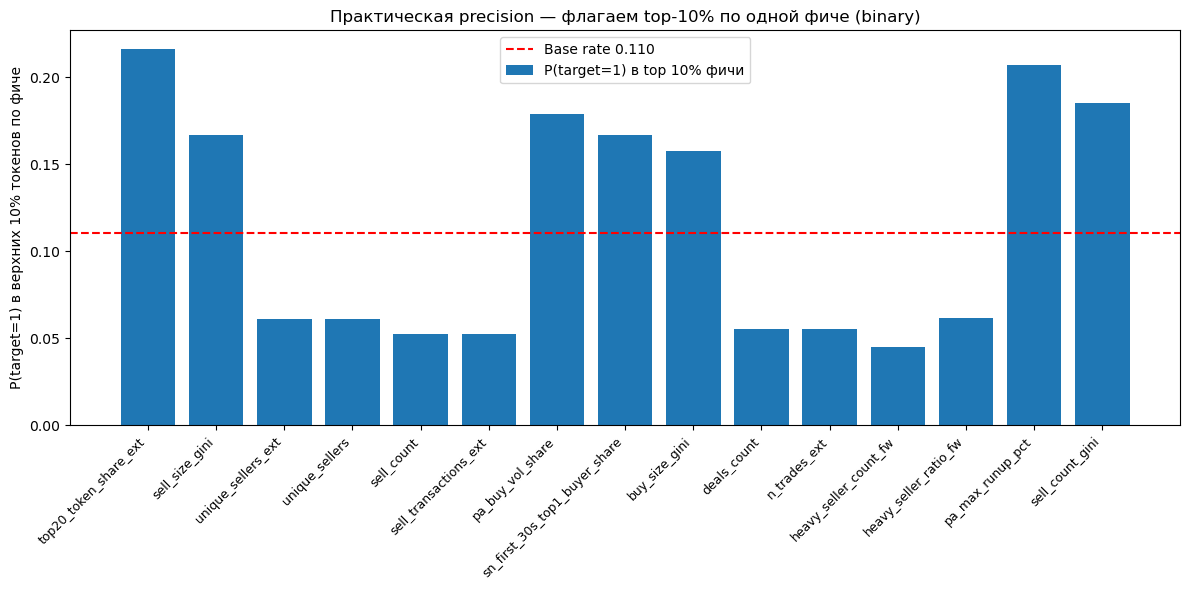

ТОП-15 фичей — top-decile P(target=1):
                      feature  top_decile_prec  bottom_decile_prec  top_over_bottom_ratio
        top20_token_share_ext           0.2160              0.0988                 2.1875
               sell_size_gini           0.1667              0.0525                 3.1765
           unique_sellers_ext           0.0613              0.2239                 0.2740
               unique_sellers           0.0613              0.2239                 0.2740
                   sell_count           0.0523              0.1738                 0.3010
        sell_transactions_ext           0.0523              0.1738                 0.3010
             pa_buy_vol_share           0.1790              0.0710                 2.5217
sn_first_30s_top1_buyer_share           0.1667              0.0648                 2.5714
                buy_size_gini           0.1574              0.0556                 2.8333
                  deals_count           0.0556              0

In [11]:
top15 = combo_sorted.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(top15))
ax.bar(x_pos, top15['top_decile_prec'].values, color='C0', label='P(target=1) в top 10% фичи')
ax.axhline(base_rate, color='red', linestyle='--', label=f'Base rate {base_rate:.3f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(top15['feature'].values, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('P(target=1) в верхних 10% токенов по фиче')
ax.set_title('Практическая precision — флагаем top-10% по одной фиче (binary)')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/feature_research/top15_top_decile_binary.png', dpi=110, bbox_inches='tight')
plt.show()

print('ТОП-15 фичей — top-decile P(target=1):')
print(top15[['feature', 'top_decile_prec', 'bottom_decile_prec',
             'top_over_bottom_ratio']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

## 9. Heavy seller фичи — отдельный фокус

Посмотрим подробнее на 2 новые фичи `heavy_seller_*`.

In [12]:
for f in ['heavy_seller_count_fw', 'heavy_seller_ratio_fw']:
    if f not in df.columns:
        continue
    idx = combo_sorted.index[combo_sorted['feature'] == f]
    if len(idx) == 0: continue
    rank = int(idx[0]) + 1
    row = combo_sorted.iloc[idx[0]]
    print(f'{f}:')
    print(f'  Rank: {rank}/{len(combo_sorted)}')
    print(f'  combined_score: {row["combined_score"]:.4f}')
    print(f'  spearman: {row["spearman"]:.4f}')
    print(f'  pearson: {row["pearson"]:.4f}')
    print(f'  gini_reduction: {row["gini_reduction"]:.5f}')
    print(f'  top_decile_prec: {row["top_decile_prec"]:.4f}  (baseline {base_rate:.4f})')
    print(f'  bottom_decile_prec: {row["bottom_decile_prec"]:.4f}')
    print(f'  top_over_bottom_ratio: {row["top_over_bottom_ratio"]:.2f}')

    x = df[f].values.astype(float)
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    bins = np.digitize(x, q_edges[1:-1])
    print(f'  По децилям P(target=1):')
    for b in range(len(q_edges) - 1):
        m = bins == b
        if m.sum() == 0: continue
        p_b = y[m].mean()
        print(f'    децил {b}: n={int(m.sum())} pos={int(y[m].sum())} P={p_b:.3f}')
    print()

heavy_seller_count_fw:
  Rank: 12/77
  combined_score: 2.9472
  spearman: -0.1313
  pearson: -0.0842
  gini_reduction: 0.00386
  top_decile_prec: 0.0449  (baseline 0.1105)
  bottom_decile_prec: 0.1785
  top_over_bottom_ratio: 0.25
  По децилям P(target=1):
    децил 0: n=301 pos=59 P=0.196
    децил 1: n=284 pos=39 P=0.137
    децил 2: n=321 pos=55 P=0.171
    децил 3: n=330 pos=48 P=0.145
    децил 4: n=365 pos=39 P=0.107
    децил 5: n=329 pos=22 P=0.067
    децил 6: n=306 pos=26 P=0.085
    децил 7: n=325 pos=22 P=0.068
    децил 8: n=336 pos=32 P=0.095
    децил 9: n=334 pos=15 P=0.045

heavy_seller_ratio_fw:
  Rank: 13/77
  combined_score: 2.8418
  spearman: -0.1129
  pearson: -0.1034
  gini_reduction: 0.00297
  top_decile_prec: 0.0617  (baseline 0.1105)
  bottom_decile_prec: 0.1865
  top_over_bottom_ratio: 0.33
  По децилям P(target=1):
    децил 0: n=323 pos=61 P=0.189
    децил 1: n=323 pos=48 P=0.149
    децил 2: n=323 pos=47 P=0.146
    децил 3: n=323 pos=47 P=0.146
    децил

## 10. Сравнение рейтингов: regression vs classification

Загружаем ранкинги обоих видов анализа и смотрим совпадают ли топ фичи.

In [13]:
reg_ranks = pd.read_csv('/tmp/feature_research/feature_influence_ranked.csv')
reg_ranks['rank_reg'] = reg_ranks.index + 1

bin_ranks = combo_sorted.copy()
bin_ranks['rank_bin'] = bin_ranks.index + 1

# Merge
m = reg_ranks[['feature', 'rank_reg', 'combined_score']].rename(
    columns={'combined_score': 'score_reg'}).merge(
    bin_ranks[['feature', 'rank_bin', 'combined_score']].rename(
        columns={'combined_score': 'score_bin'}),
    on='feature')
m['rank_diff'] = m['rank_bin'] - m['rank_reg']
m_sorted = m.sort_values('rank_bin').head(20)
print('Сравнение топ-20 в binary vs regression ranking:')
print(m_sorted[['feature', 'rank_reg', 'rank_bin', 'rank_diff', 'score_reg', 'score_bin']].to_string(
    index=False, float_format=lambda x: f'{x:.3f}'))

# Сколько фичей совпадают в топ-10?
top10_reg = set(reg_ranks.head(10)['feature'])
top10_bin = set(bin_ranks.head(10)['feature'])
print(f'\nTop-10 совпадают: {len(top10_reg & top10_bin)} из 10')
print(f'Совпавшие: {sorted(top10_reg & top10_bin)}')
print(f'Только в regression: {sorted(top10_reg - top10_bin)}')
print(f'Только в binary: {sorted(top10_bin - top10_reg)}')

Сравнение топ-20 в binary vs regression ranking:
                      feature  rank_reg  rank_bin  rank_diff  score_reg  score_bin
        top20_token_share_ext         1         1          0      4.436      4.468
               sell_size_gini        16         2        -14      2.662      3.576
           unique_sellers_ext        60         3        -57      1.282      3.480
               unique_sellers        61         4        -57      1.282      3.480
                   sell_count        68         5        -63      1.007      3.206
        sell_transactions_ext        67         6        -61      1.007      3.206
             pa_buy_vol_share         2         7          5      4.016      3.171
sn_first_30s_top1_buyer_share        41         8        -33      1.807      3.114
                buy_size_gini        57         9        -48      1.419      3.011
                  deals_count        75        10        -65      0.820      3.000
                 n_trades_ext        7

## 11. Итоги

### Что сделано
- Анализ 77 фичей против **бинарного таргета** (target = 1 если x≥5)
- 6 метрик + биномиальные тесты + корреляция + графики

### Как использовать
- Combined score — ранкинг фичей по общему влиянию на бинарную задачу
- Топ фичи с p-value < 0.001 — надёжный сигнал, статистически устойчивы
- Сравнение с регрессионным рейтингом показывает какие фичи универсальны, а какие работают только для "magnitude" предсказания

### Рекомендации
- Использовать combined score как приоритет при feature selection
- Фичи в топ-10 и regression, и binary — самый надёжный сигнал
- Heavy seller фичи — слабый anti-signal, могут помочь как фильтр

In [14]:
# Сохраняем финальный ранкинг
combo_sorted[['feature', 'spearman', 'pearson', 'decile_monot_r2_signed',
              'gini_reduction', 'top_decile_prec', 'top_over_bottom_ratio',
              'combined_score']].to_csv(
    '/tmp/feature_research/feature_influence_binary_ranked.csv', index=False)
print('Сохранил /tmp/feature_research/feature_influence_binary_ranked.csv')
combo_sorted.head(30)[['feature', 'combined_score', 'spearman', 'gini_reduction', 'top_decile_prec']]

Сохранил /tmp/feature_research/feature_influence_binary_ranked.csv


,feature,combined_score,spearman,gini_reduction,top_decile_prec
0,top20_token_share_ext,4.468457,0.128387,0.005204,0.216049
1,sell_size_gini,3.575815,0.126877,0.003037,0.166667
2,unique_sellers_ext,3.479625,-0.149402,0.004599,0.061350
3,unique_sellers,3.479625,-0.149402,0.004599,0.061350
4,sell_count,3.206075,-0.132300,0.004118,0.052308
5,sell_transactions_ext,3.206075,-0.132300,0.004118,0.052308
6,pa_buy_vol_share,3.171497,0.090229,0.003639,0.179012
7,sn_first_30s_top1_buyer_share,3.113807,0.094525,0.001832,0.166667
8,buy_size_gini,3.010791,0.118558,0.003427,0.157407
9,deals_count,3.000258,-0.122127,0.003122,0.055556
